# CTMC Journey Models: Success vs 60-Day Inactivity Failure

This notebook compares the retained CTMC baselines against two timeout-aware models. The key target distinction is:

- old CTMC target: `P(hit order_shipped state 28 within a horizon | current state)`
- classification target: `P(success before failure by 60 days of customer inactivity | current state)`

Company/system events are not treated as customer actions for the inactivity clock.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src" / "models"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "visualizations"))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score

from ctmc import (
    CTMCData,
    ClusteredCTMC,
    GlobalCTMC,
    SemiMarkovTimeoutModel,
    TimeoutAbsorbingCTMC,
    FAILURE_STATE,
    SUCCESS_STATE,
)
from ctmc_plots import (
    plot_aesthetic_state_space_graph,
    plot_generator_heatmap,
    plot_journey_success_probability_over_time,
    plot_top_transition_graph,
    plotly_timeout_probability_over_time,
)
from IPython.display import Image

MAX_JOURNEYS = 100_000
N_CLUSTERS = 3
USE_SPECTRAL_CLUSTERING = False
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 80)

## Event Definitions and State Choice

The event definition file mixes customer actions with company/system states. For inactivity failure, company/system events should not reset the 60-day clock. The models below use customer-action states plus terminal `order_shipped=28` where needed.

In [2]:
data = CTMCData()
event_defs = pd.read_csv(PROJECT_ROOT / "data" / "Event Definitions.csv")
customer_states = data.customer_action_states(include_success=False)

event_defs["used_as_customer_action_state"] = event_defs["event_definition_id"].isin(customer_states)
display(event_defs.sort_values("event_definition_id"))
print("Customer action states:", sorted(customer_states))
print("Success terminal state:", SUCCESS_STATE, "Failure terminal state:", FAILURE_STATE)

,event_name,journey_id,event_definition_id,milestone_number,stage,used_as_customer_action_state
10,campaign_click,1,2,NaN,Discover,True
6,application_web_submit,1,3,NaN,Apply for Credit,True
21,browse_products,1,4,NaN,First Purchase,True
24,view_cart,1,5,NaN,First Purchase,True
20,begin_checkout,1,6,NaN,First Purchase,True
23,place_order_web,1,7,2.0,First Purchase,True
17,place_downpayment,1,8,4.0,Downpayment,True
11,customer_requested_catalog_digital,1,9,NaN,Discover,True
12,fingerhut_university,1,10,NaN,Discover,True
19,add_to_cart,1,11,NaN,First Purchase,True


Customer action states: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 18, 19, 22, 23, 25]
Success terminal state: 28 Failure terminal state: -1


## Build Transition Tables

`transitions` is the old CTMC transition table, but filtered to customer-action states plus success. `timeout_transitions` adds an absorbing failure state for incomplete journeys after 60 days with no customer action.

In [3]:
transitions = data.transition_table(
    max_journeys=MAX_JOURNEYS,
    customer_actions_only=True,
    include_success=True,
)
timeout_transitions = data.timeout_transition_table(max_journeys=MAX_JOURNEYS)

print("customer-action CTMC transitions:", transitions.shape, "journeys:", transitions["id"].nunique())
print("timeout-aware transitions:", timeout_transitions.shape, "journeys:", timeout_transitions["id"].nunique())
display(transitions.head())
display(timeout_transitions.tail())

customer-action CTMC transitions: (2731520, 4) journeys: 88648
timeout-aware transitions: (1385115, 4) journeys: 95083


,id,state,next_state,dt_seconds
1,-1000001271 551641434,4,19,24.0
2,-1000001271 551641434,19,19,3.0
3,-1000001271 551641434,19,19,2.0
4,-1000001271 551641434,19,2,21498.0
5,-1000001271 551641434,2,4,2846848.0


,id,state,next_state,dt_seconds
2746731,-1303783106 -1331962655,19,-1,5184000.0
2746732,-1303785126 -1269952066,4,-1,5184000.0
2746733,-1303788107 2139060553,18,-1,5184000.0
2746734,-1303796977 -1056334630,6,-1,5184000.0
2746735,-1303809893 284896680,4,-1,5184000.0


## Old Baseline 1: Global CTMC

This still computes `P(hit order_shipped within 60 days | current state)`. It is useful, but it is not the exact failure-vs-success target.

In [4]:
global_ctmc = GlobalCTMC().fit(transitions)
print("Q shape:", global_ctmc.Q_.shape)
display(global_ctmc.top_rates(20))

plot_generator_heatmap(global_ctmc, RESULTS_DIR / "ctmc_customer_action_generator_heatmap.png")
plot_top_transition_graph(global_ctmc, RESULTS_DIR / "ctmc_customer_action_top_transition_graph.png")

Q shape: (14, 14)


,from_state,to_state,rate
78,10,5,8.271299e-04
77,10,4,8.271299e-04
81,11,4,1.592117e-05
82,11,5,1.589819e-05
61,7,8,1.495567e-05
18,3,19,1.361943e-05
28,4,11,4.818087e-06
35,5,4,3.057003e-06
36,5,6,2.922006e-06
100,19,3,2.825018e-06


## Single-Journey Probability Path Under the Global CTMC

For the global CTMC, a journey's score changes only when the current customer-action state changes. The plot below follows one observed journey over time and recomputes P(order_shipped within 60 days | current state) after every user action. Action markers are drawn just before the vertical update so increases are visually attributed to the action that triggered them.


,id,event_timestamp,elapsed_days,ed_id,event_label,success_probability,delta_probability
0,-1067752691 -1299034859,2021-11-27 21:19:14+00:00,0.000000,23,site_registration,0.335167,0.000000
1,-1067752691 -1299034859,2021-11-27 21:23:36+00:00,0.003032,4,browse_products,0.404626,0.069459
2,-1067752691 -1299034859,2022-05-26 10:41:05+00:00,179.556840,18,place_order_phone,0.683339,0.278712
3,-1067752691 -1299034859,2022-06-01 00:00:00+00:00,185.111644,28,order_shipped,1.000000,0.316661


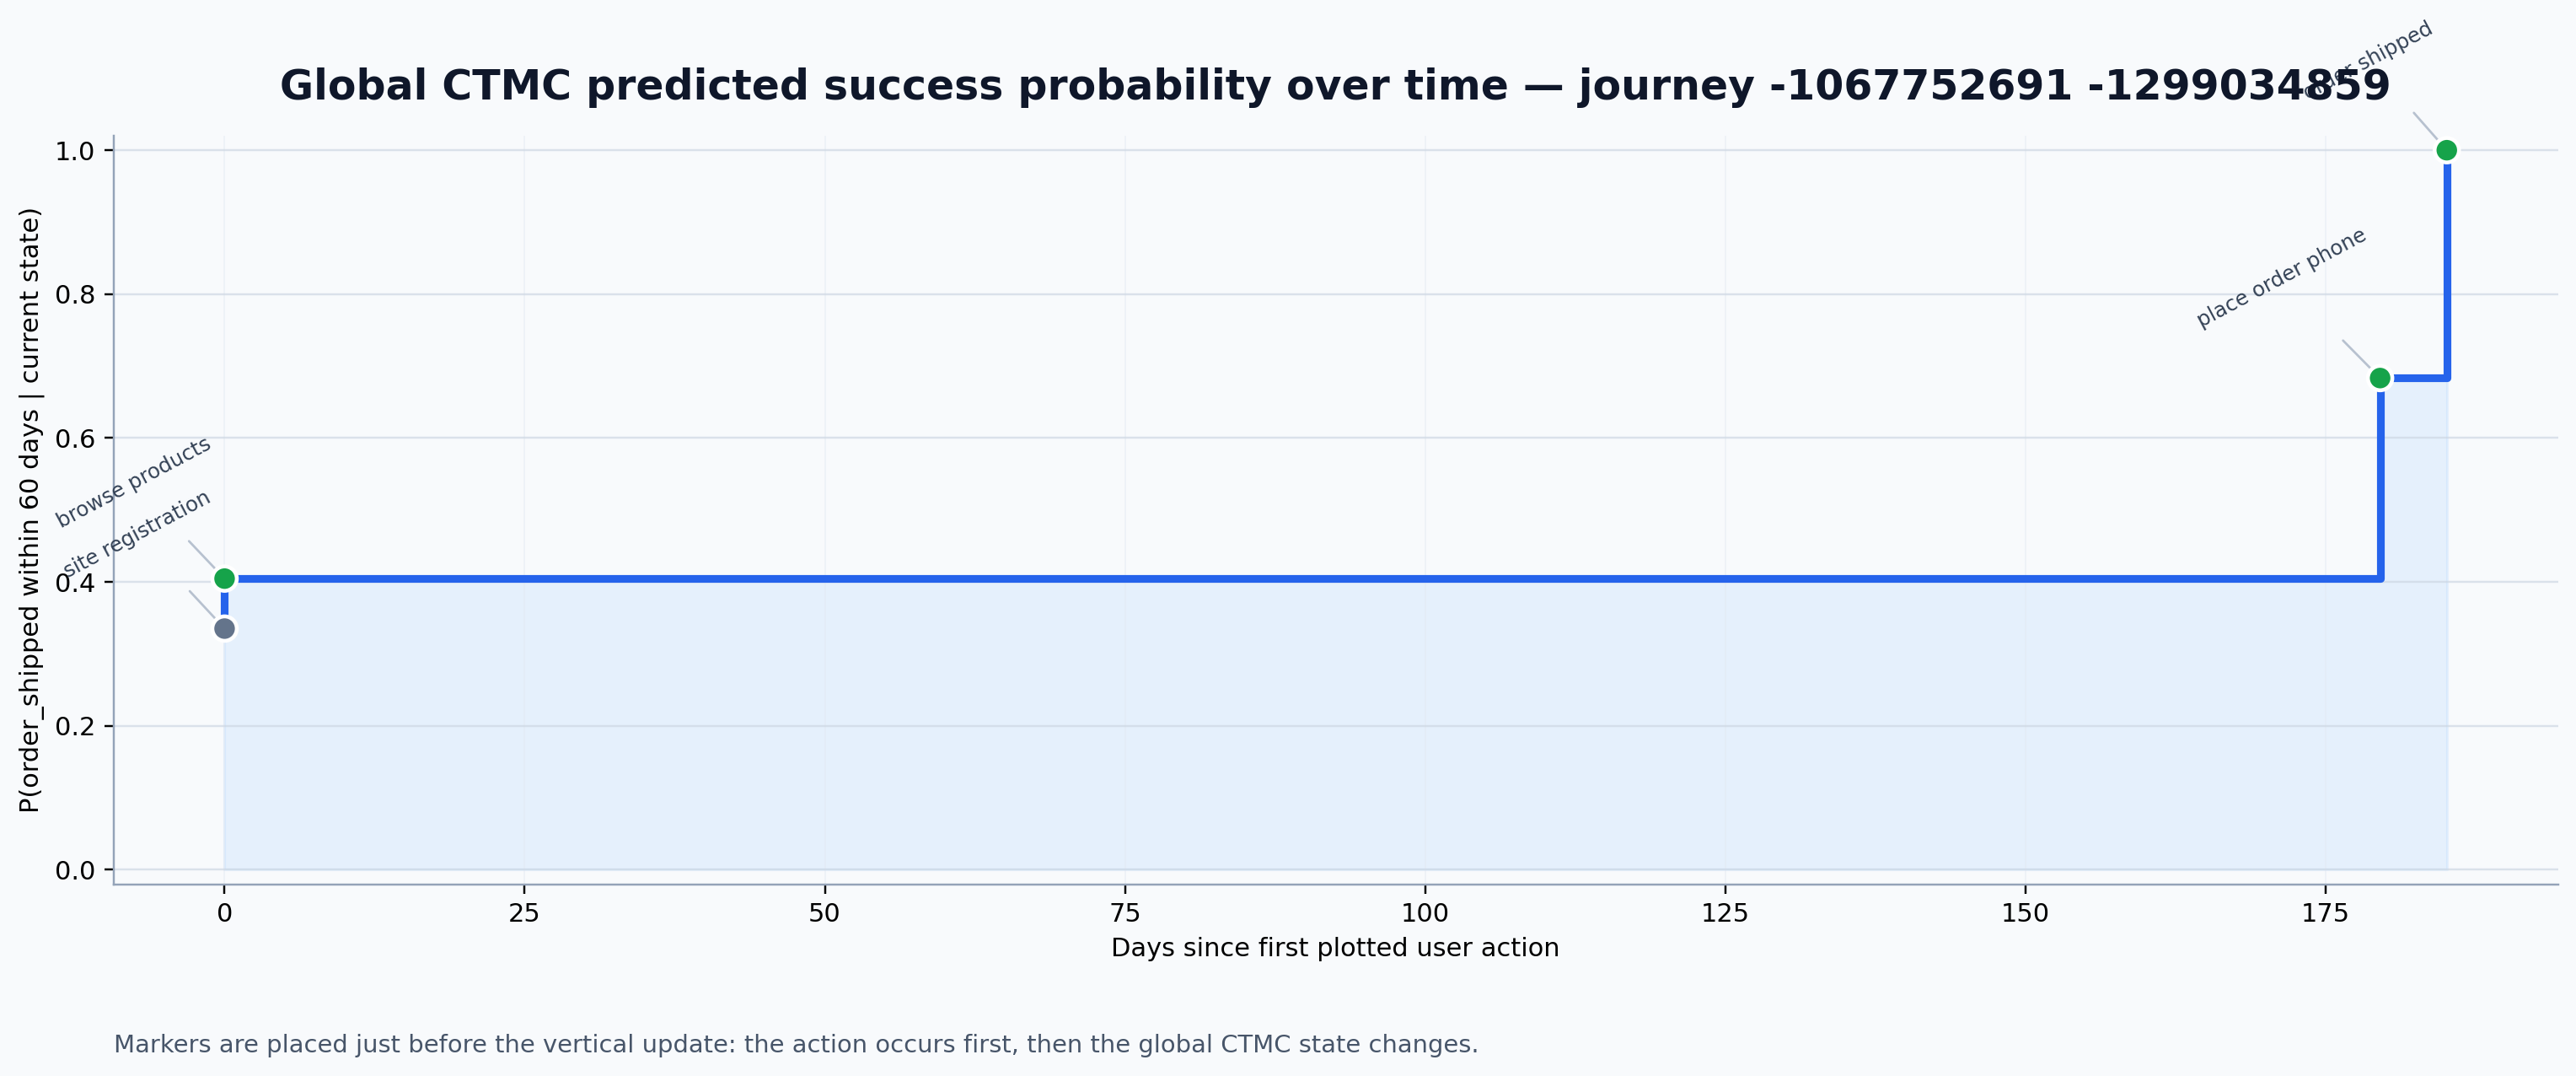

In [5]:
# Use customer-action events, including the success state, so every plotted action
# is part of the global CTMC state space.
journey_plot_events = data.events(
    max_journeys=MAX_JOURNEYS,
    customer_actions_only=True,
    include_success=True,
)
journey_plot_events["state_probability"] = global_ctmc.absorption_probability(
    journey_plot_events["ed_id"].to_numpy(),
    success_state=SUCCESS_STATE,
    horizon_seconds=60 * 24 * 60 * 60,
)

# Pick an illustrative journey automatically: enough user actions to show a path,
# and a visible probability range so the plot is not flat.
journey_candidates = (
    journey_plot_events
    .groupby("id")
    .agg(
        n_actions=("ed_id", "size"),
        p_min=("state_probability", "min"),
        p_max=("state_probability", "max"),
        reached_success=("ed_id", lambda s: bool((s == SUCCESS_STATE).any())),
    )
    .assign(p_range=lambda d: d["p_max"] - d["p_min"])
    .query("n_actions >= 4")
    .sort_values(["reached_success", "p_range", "n_actions"], ascending=[False, False, True])
)

JOURNEY_ID_FOR_PLOT = journey_candidates.index[0]
journey_probability_path = plot_journey_success_probability_over_time(
    journey_plot_events,
    global_ctmc,
    RESULTS_DIR / "ctmc_global_single_journey_probability_path.png",
    event_defs=event_defs,
    journey_id=JOURNEY_ID_FOR_PLOT,
    customer_states=customer_states,
    success_state=SUCCESS_STATE,
    horizon_days=60,
)

display(journey_probability_path)
display(Image(filename=str(RESULTS_DIR / "ctmc_global_single_journey_probability_path.png")))

## Old Baseline 2: Clustered CTMC

This is the retained segmented CTMC baseline. Set `USE_SPECTRAL_CLUSTERING = True` in the first code cell to compare spectral clustering against KMeans.

,cluster,n_journeys
0,0,28340
1,1,17168
2,2,43140


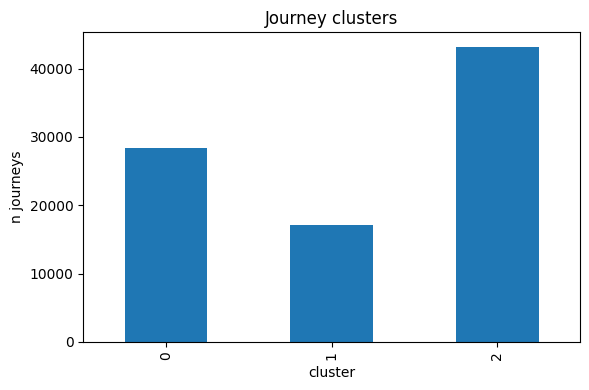

In [6]:
clustered = ClusteredCTMC(
    n_clusters=N_CLUSTERS,
    random_state=42,
    use_spectral_clustering=USE_SPECTRAL_CLUSTERING,
).fit(transitions)
cluster_summary = clustered.cluster_summary()
display(cluster_summary)

cluster_summary.plot.bar(x="cluster", y="n_journeys", legend=False, figsize=(6, 4))
plt.title("Journey clusters")
plt.ylabel("n journeys")
plt.tight_layout()
plt.show()

features = clustered.feature_builder.transform(transitions)

## New Model 1: Timeout-Absorbing CTMC

This augments the CTMC state space with an absorbing failure state. It estimates competing rates to success and failure, then solves for `P(absorb in success before failure)`.

In [7]:
timeout_ctmc = TimeoutAbsorbingCTMC().fit(timeout_transitions)
timeout_probs_by_state = pd.DataFrame({
    "state": timeout_ctmc.states_,
    "p_success_before_timeout_failure": timeout_ctmc.predict_success_probability(timeout_ctmc.states_),
}).sort_values("p_success_before_timeout_failure", ascending=False)
display(timeout_probs_by_state)

,state,p_success_before_timeout_failure
14,28,1.000000
7,8,0.581516
6,7,0.548851
10,18,0.478226
5,6,0.295282
4,5,0.273245
9,11,0.264243
8,10,0.262059
3,4,0.256465
2,3,0.222239


## Timeout-Absorbing CTMC State-Space Graph

This is the more interpretable state-space graph for our final CTMC framing: ordinary customer-action states can flow either toward order_shipped or into the explicit 60-day inactivity failure absorbing state. Edge thickness reflects the fitted transition rate, and the two terminal outcomes are colored separately.


,from_state,to_state,rate
85,10,4,1.443001e-03
86,10,5,7.215007e-04
91,11,5,9.080752e-06
90,11,4,8.720573e-06
21,3,19,6.378999e-06
68,7,8,5.809477e-06
84,8,28,1.495694e-06
40,5,4,1.460512e-06
41,5,6,1.425606e-06
76,8,4,1.276554e-06


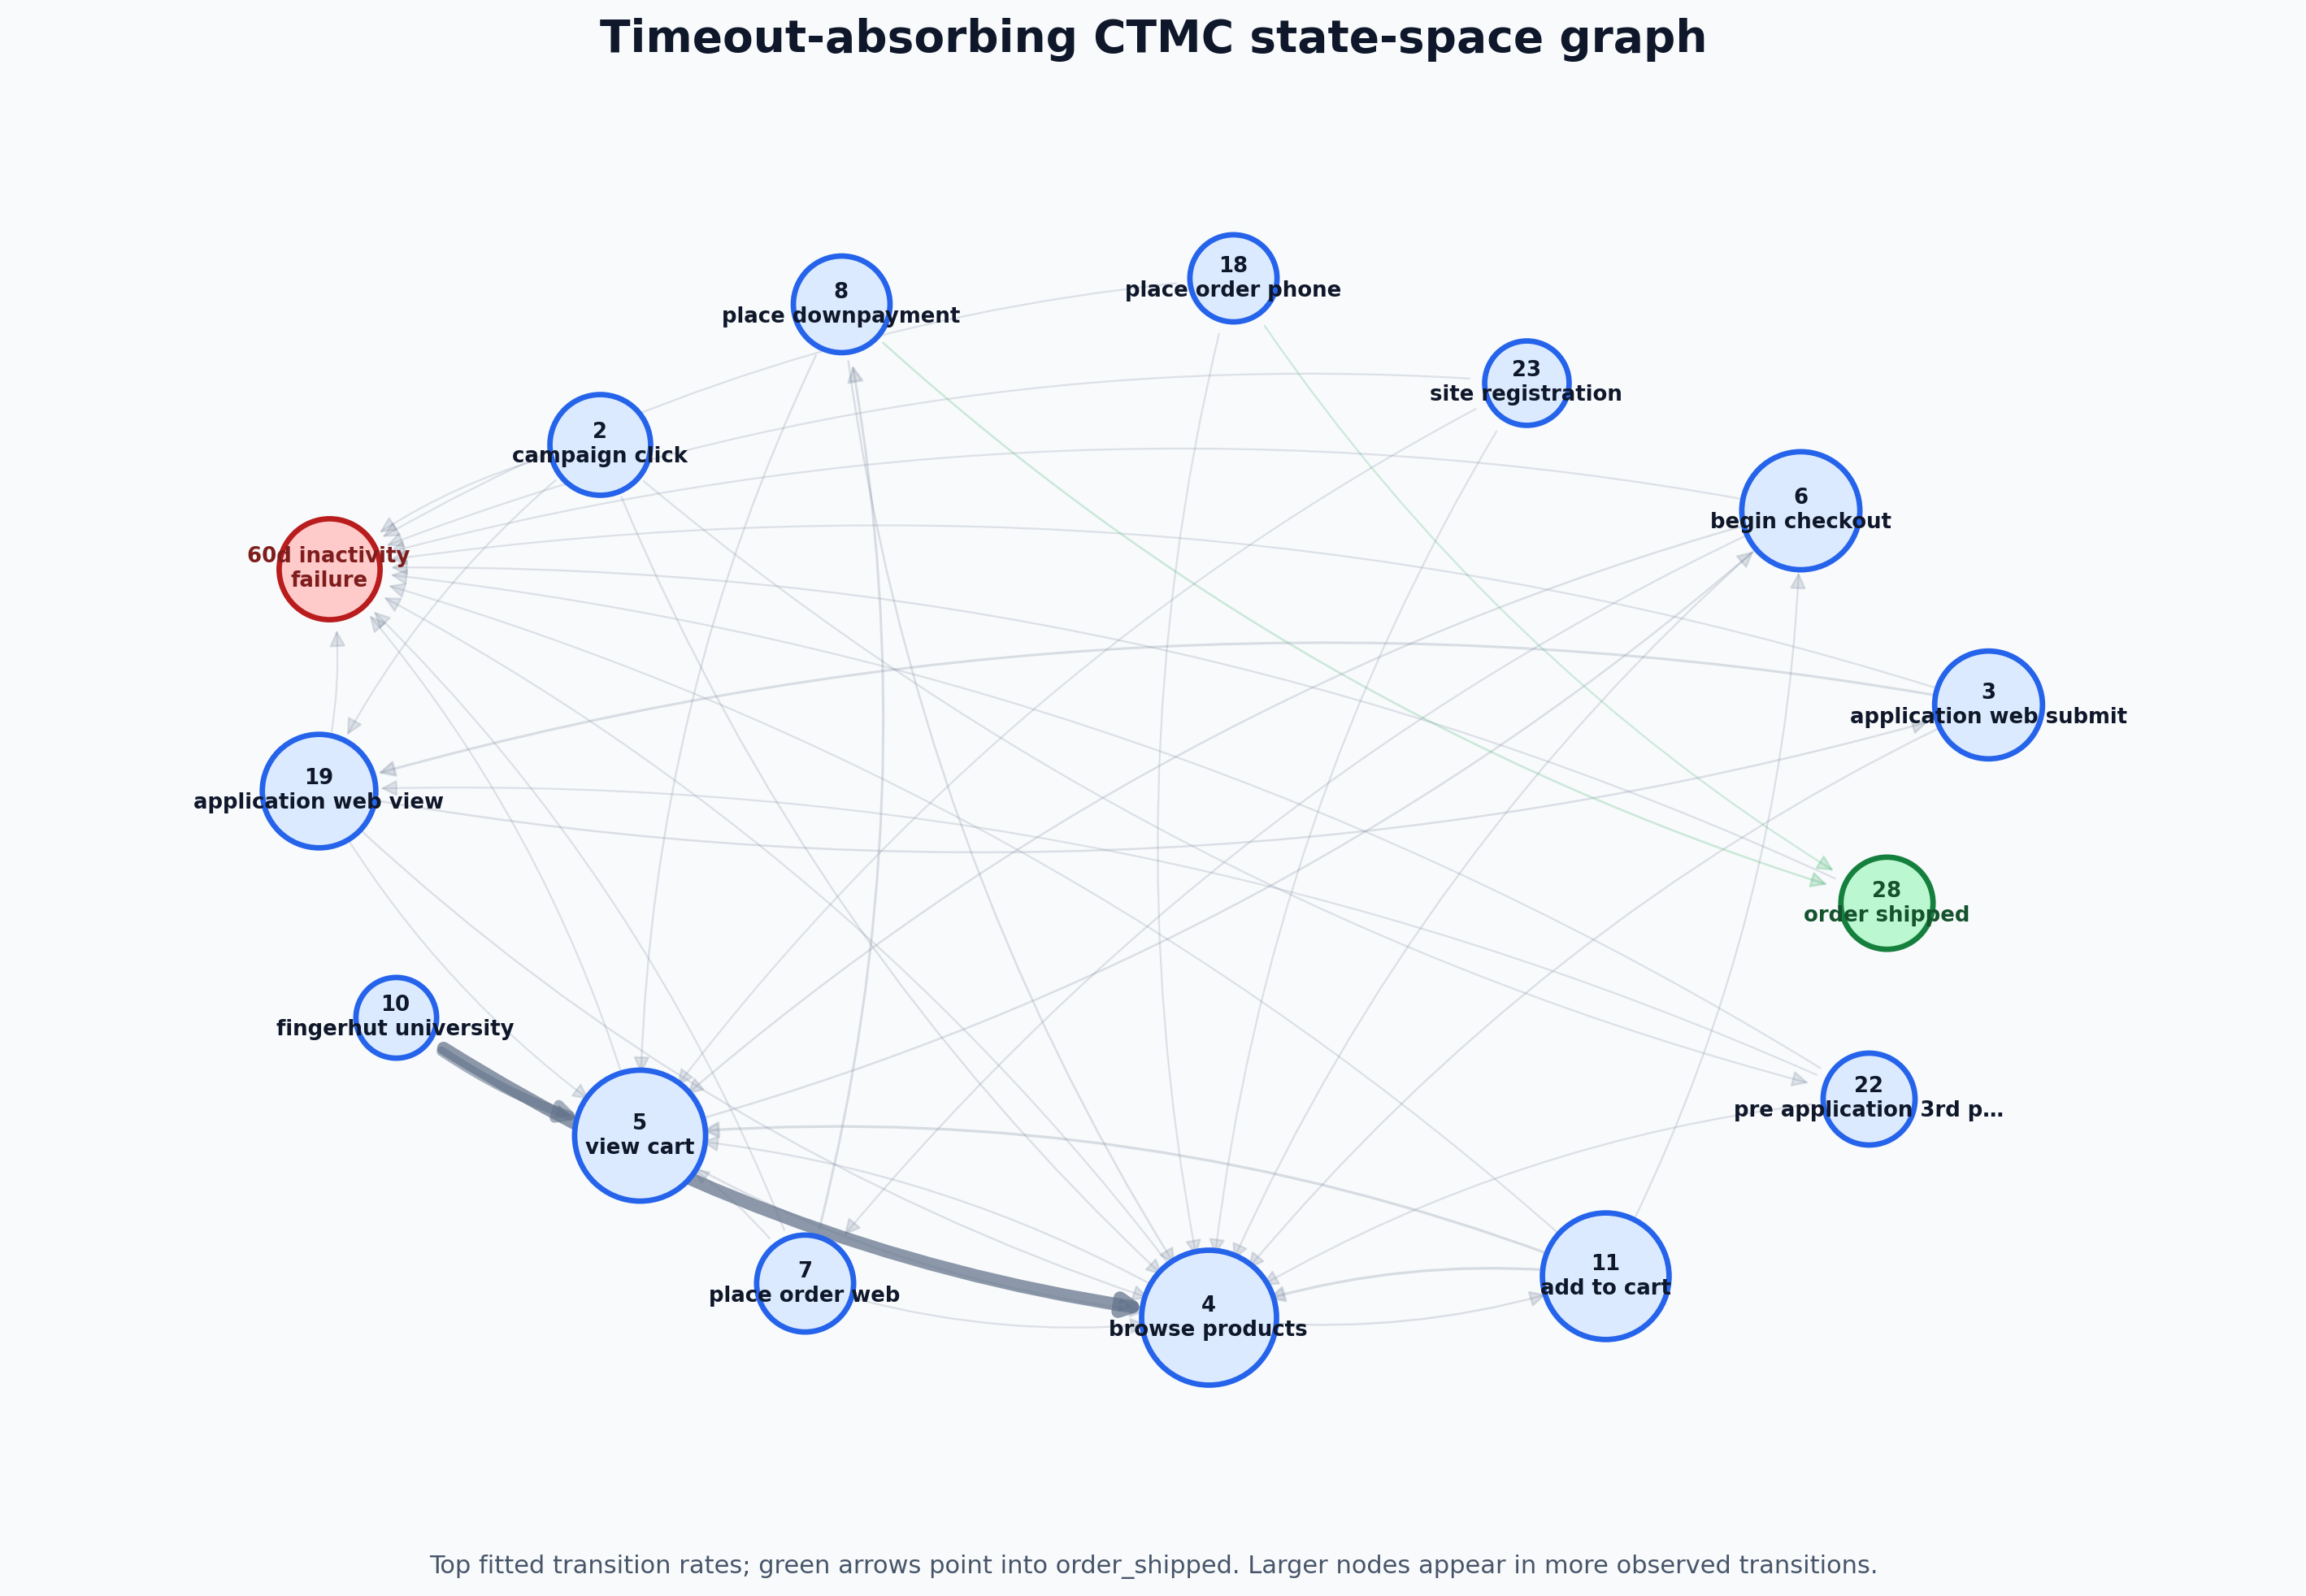

In [8]:
timeout_state_space_graph_path = RESULTS_DIR / "ctmc_timeout_absorbing_state_space_graph.png"
timeout_state_space_edges = plot_aesthetic_state_space_graph(
    timeout_ctmc,
    timeout_state_space_graph_path,
    event_defs=event_defs,
    n_edges=44,
    success_state=SUCCESS_STATE,
    title="Timeout-absorbing CTMC state-space graph",
)
display(timeout_state_space_edges.head(16))
display(Image(filename=str(timeout_state_space_graph_path)))

## Interactive Timeout-Absorbing Probability Path

The static journey plot above uses the old global CTMC success-within-horizon score. The interactive Plotly version below uses the timeout-absorbing CTMC instead, so the y-axis is the probability of reaching order_shipped before the explicit 60-day inactivity-failure state. Each marker is labeled by state id and, on hover, the action name from Event Definitions.csv.


In [9]:
# Reuse the same candidate-selection idea, but score with the timeout-absorbing CTMC.
timeout_journey_plot_events = data.events(
    max_journeys=MAX_JOURNEYS,
    customer_actions_only=True,
    include_success=True,
)
timeout_journey_plot_events["timeout_success_probability"] = timeout_ctmc.predict_success_probability(
    timeout_journey_plot_events["ed_id"].to_numpy(),
    success_state=SUCCESS_STATE,
    horizon_seconds=60 * 24 * 60 * 60,
)

timeout_journey_candidates = (
    timeout_journey_plot_events
    .groupby("id")
    .agg(
        n_actions=("ed_id", "size"),
        p_min=("timeout_success_probability", "min"),
        p_max=("timeout_success_probability", "max"),
        reached_success=("ed_id", lambda s: bool((s == SUCCESS_STATE).any())),
    )
    .assign(p_range=lambda d: d["p_max"] - d["p_min"])
    .query("n_actions >= 4")
    .sort_values(["reached_success", "p_range", "n_actions"], ascending=[False, False, True])
)

TIMEOUT_JOURNEY_ID_FOR_PLOT = timeout_journey_candidates.index[0]
timeout_probability_fig, timeout_probability_path = plotly_timeout_probability_over_time(
    timeout_journey_plot_events,
    timeout_ctmc,
    event_defs=event_defs,
    journey_id=TIMEOUT_JOURNEY_ID_FOR_PLOT,
    customer_states=customer_states,
    success_state=SUCCESS_STATE,
    horizon_days=60,
)

display(timeout_probability_path)
timeout_probability_fig.show()

,id,event_timestamp,elapsed_days,ed_id,action_name,state_action_label,success_probability,delta_probability,direction
0,-1082482231 691013218,2021-05-31 06:00:00+00:00,0.000000,2,campaign_click,2 — campaign click,0.206190,0.000000,unchanged
1,-1082482231 691013218,2021-05-31 06:00:00+00:00,0.000000,22,pre_application_3rd_party_affiliates,22 — pre application 3rd party affiliates,0.180481,-0.025708,decrease
2,-1082482231 691013218,2021-06-22 13:35:41+00:00,22.316447,18,place_order_phone,18 — place order phone,0.478226,0.297744,increase
3,-1082482231 691013218,2021-06-26 00:00:00+00:00,25.750000,28,order_shipped,28 — order shipped,1.000000,0.521774,increase


## New Model 2: Empirical Semi-Markov Timeout Model

This model does not assume exponential waiting times. It uses observed outgoing transition samples and treats waits over 60 days as failure. It estimates the recursive probability of eventually reaching success before a timeout.

In [10]:
semi_markov = SemiMarkovTimeoutModel().fit(timeout_transitions)
semi_probs_by_state = pd.DataFrame({
    "state": semi_markov.states_,
    "p_success_before_timeout_failure": semi_markov.predict_success_probability(semi_markov.states_),
}).sort_values("p_success_before_timeout_failure", ascending=False)
display(semi_probs_by_state)

,state,p_success_before_timeout_failure
14,28,1.000000
7,8,0.566032
6,7,0.532390
10,18,0.464014
5,6,0.266734
4,5,0.244832
9,11,0.236448
8,10,0.234789
3,4,0.229767
2,3,0.192981


## Diagnostic Comparison on Resolved Journeys

This joins model scores to resolved labels. It is diagnostic rather than a perfect offline validation because these features are built from completed journeys. For Kaggle-style evaluation, prefer open/test-prefix submissions.

In [11]:
labels = data.load_binary_labels()
eval_df = features.merge(labels, on="id", how="inner")

predictions = {
    "global_ctmc_old_target": global_ctmc.absorption_probability(eval_df["current_state"]),
    "clustered_ctmc_old_target": clustered.predict_success_probability(eval_df, fallback_model=global_ctmc),
    "timeout_absorbing_ctmc": timeout_ctmc.predict_success_probability(eval_df["current_state"]),
    "semi_markov_timeout": semi_markov.predict_success_probability(eval_df["current_state"]),
}

y = eval_df["label"].astype(int).to_numpy()
rows = []
for name, probs in predictions.items():
    probs = pd.Series(probs).clip(1e-6, 1 - 1e-6).to_numpy()
    rows.append({
        "model": name,
        "brier_score": brier_score_loss(y, probs),
        "log_loss": log_loss(y, probs, labels=[0, 1]),
        "roc_auc": roc_auc_score(y, probs),
        "average_precision": average_precision_score(y, probs),
        "mean_prob": probs.mean(),
    })

comparison = pd.DataFrame(rows).sort_values("brier_score")
comparison.to_csv(RESULTS_DIR / "ctmc_timeout_model_comparison.csv", index=False)
display(comparison)

,model,brier_score,log_loss,roc_auc,average_precision,mean_prob
1,clustered_ctmc_old_target,0.014447,0.089786,0.999949,0.99969,0.313809
3,semi_markov_timeout,0.042088,0.201114,0.999949,0.99969,0.419891
2,timeout_absorbing_ctmc,0.052110,0.228482,0.999949,0.99969,0.440540
0,global_ctmc_old_target,0.122606,0.389901,0.999949,0.99969,0.547931


## Per-State Probability Comparison

,state,global_hit_success_60d,timeout_absorbing_success_before_failure,semi_markov_success_before_failure
6,8,0.656768,0.581516,0.566032
5,7,0.635748,0.548851,0.532390
9,18,0.683339,0.478226,0.464014
4,6,0.417938,0.295282,0.266734
3,5,0.406118,0.273245,0.244832
8,11,0.403690,0.264243,0.236448
7,10,0.405335,0.262059,0.234789
2,4,0.404626,0.256465,0.229767
1,3,0.366277,0.222239,0.192981
10,19,0.367795,0.221947,0.192979


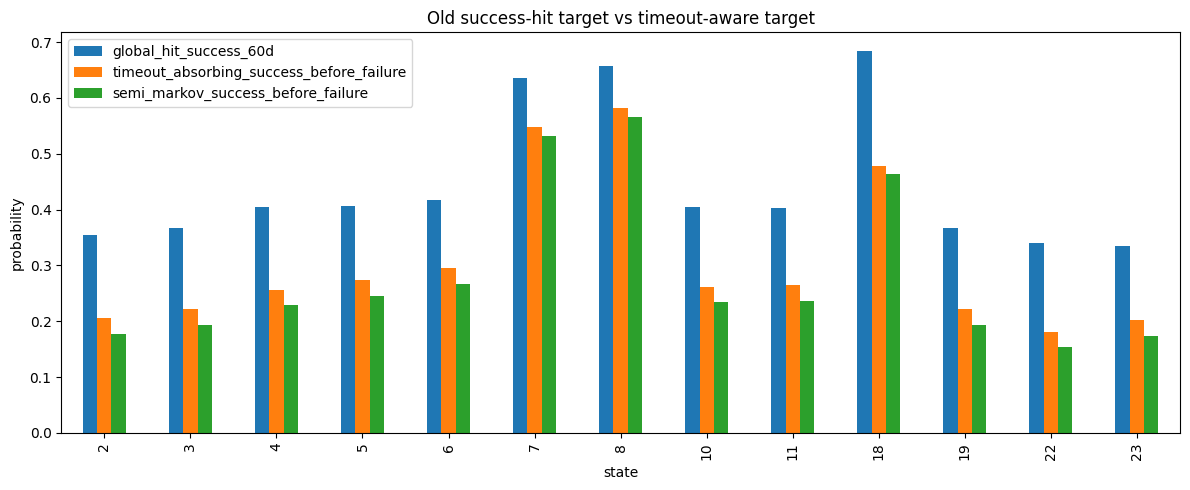

In [12]:
all_states = sorted(set(global_ctmc.states_) | set(timeout_ctmc.states_) | set(semi_markov.states_))
all_states = [s for s in all_states if s not in {SUCCESS_STATE, FAILURE_STATE}]
state_comparison = pd.DataFrame({
    "state": all_states,
    "global_hit_success_60d": global_ctmc.absorption_probability(all_states),
    "timeout_absorbing_success_before_failure": timeout_ctmc.predict_success_probability(all_states),
    "semi_markov_success_before_failure": semi_markov.predict_success_probability(all_states),
})
display(state_comparison.sort_values("timeout_absorbing_success_before_failure", ascending=False))

state_comparison.set_index("state").plot.bar(figsize=(12, 5))
plt.ylabel("probability")
plt.title("Old success-hit target vs timeout-aware target")
plt.tight_layout()
plt.show()

## Submission Commands

From PowerShell, run the full retained CTMC set:

```powershell
python -m src.models.ctmc_pipeline all --no-cache
```

Run only spectral clustered CTMC:

```powershell
python -m src.models.ctmc_pipeline clustered --use-spectral-clustering --no-cache
```